In [1]:
import pandas as pd

df = pd.read_csv('bank-additional-full.csv', sep=';')
print("Redovi,Kolone")
print(df.shape)
df.head()

Redovi,Kolone
(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


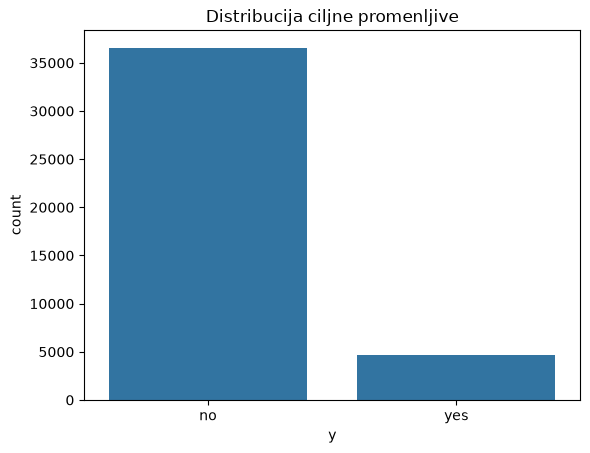

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='y', data=df)
plt.title('Distribucija ciljne promenljive')
plt.show()

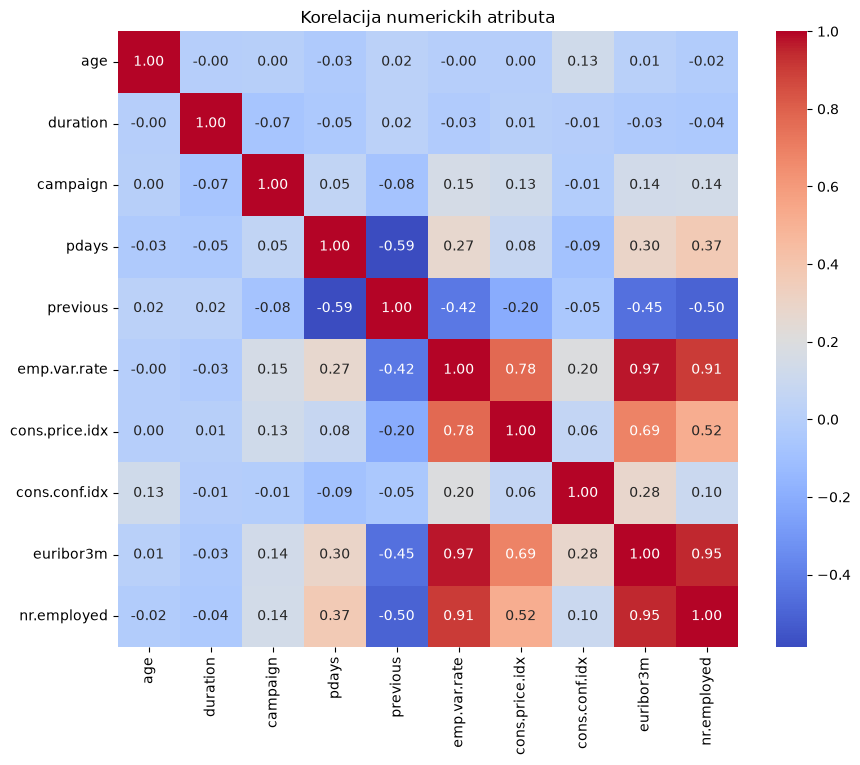

In [3]:
plt.figure(figsize=(10,8))
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelacija numerickih atributa')
plt.show()

In [4]:
#KATEGORIJSKI ATRIBUTI

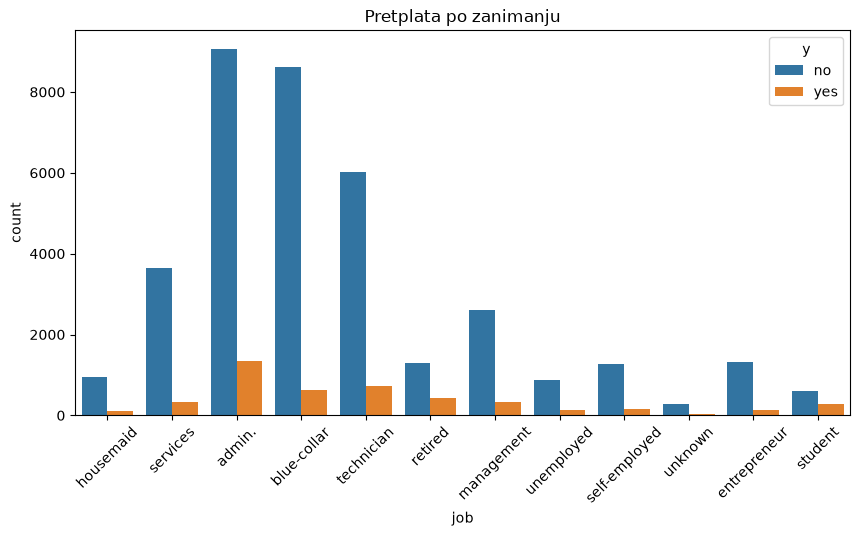

In [5]:
plt.figure(figsize=(10,5))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title('Pretplata po zanimanju')
plt.show()

In [6]:
job_yes_rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean() * 100)
print(job_yes_rate.sort_values(ascending=False))

job
student          31.428571
retired          25.232558
unemployed       14.201183
admin.           12.972558
management       11.217510
unknown          11.212121
technician       10.826042
self-employed    10.485574
housemaid        10.000000
entrepreneur      8.516484
services          8.138070
blue-collar       6.894316
Name: y, dtype: float64


In [7]:
cat_cols_to_check = [ 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

for col in cat_cols_to_check:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['y'].apply(lambda x: (x=='yes').mean() * 100).sort_values(ascending=False).round(2))


--- marital ---
marital
unknown     15.00
single      14.00
divorced    10.32
married     10.16
Name: y, dtype: float64

--- education ---
education
illiterate             22.22
unknown                14.50
university.degree      13.72
professional.course    11.35
high.school            10.84
basic.4y               10.25
basic.6y                8.20
basic.9y                7.82
Name: y, dtype: float64

--- default ---
default
no         12.88
unknown     5.15
yes         0.00
Name: y, dtype: float64

--- housing ---
housing
yes        11.62
no         10.88
unknown    10.81
Name: y, dtype: float64

--- loan ---
loan
no         11.34
yes        10.93
unknown    10.81
Name: y, dtype: float64

--- contact ---
contact
cellular     14.74
telephone     5.23
Name: y, dtype: float64

--- month ---
month
mar    50.55
dec    48.90
sep    44.91
oct    43.87
apr    20.48
aug    10.60
jun    10.51
nov    10.14
jul     9.05
may     6.43
Name: y, dtype: float64

--- day_of_week ---
day_of_week
thu  

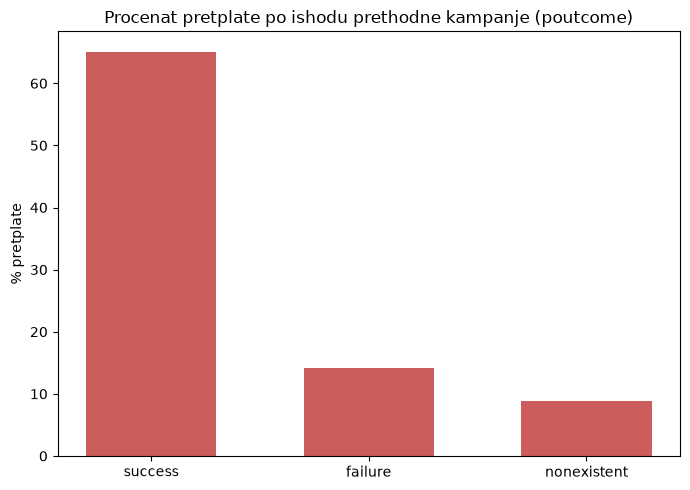

In [8]:
import matplotlib.pyplot as plt

# Procenat pretplate (y == 'yes') po ishodu prethodne kampanje, opadajuće
poutcome_rate = (
    df.groupby('poutcome')['y']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(poutcome_rate.index, poutcome_rate.values, color='indianred', width=0.6)

ax.set_title('Procenat pretplate po ishodu prethodne kampanje (poutcome)')
ax.set_ylabel('% pretplate')
ax.set_ylim(0, poutcome_rate.max() * 1.05)

plt.tight_layout()
plt.show()

In [9]:
#NUMERICKI ATRIBUTI

In [10]:
numeric_to_check = ['age', 'duration', 'campaign', 'pdays', 'previous']

for col in numeric_to_check:
    print(f"\n--- {col} ---")
    print(df.groupby('y')[col].mean().round(2))


--- age ---
y
no     39.91
yes    40.91
Name: age, dtype: float64

--- duration ---
y
no     220.84
yes    553.19
Name: duration, dtype: float64

--- campaign ---
y
no     2.63
yes    2.05
Name: campaign, dtype: float64

--- pdays ---
y
no     984.11
yes    792.04
Name: pdays, dtype: float64

--- previous ---


y
no     0.13
yes    0.49
Name: previous, dtype: float64


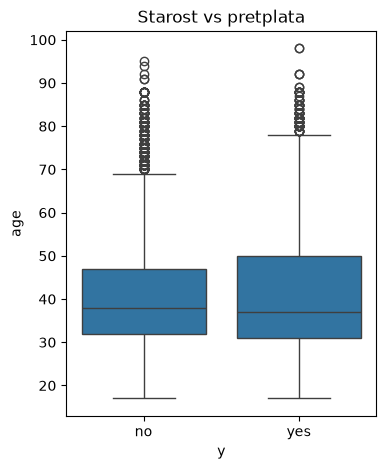

In [11]:
plt.figure(figsize=(4,5))
sns.boxplot(x='y', y='age', data=df)
plt.title('Starost vs pretplata')
plt.show()

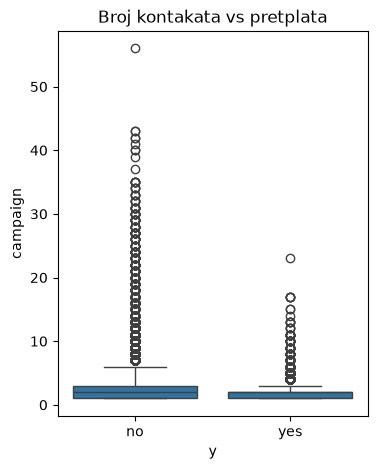

In [12]:
plt.figure(figsize=(4,5))
sns.boxplot(x='y', y='campaign', data=df)
plt.title('Broj kontakata vs pretplata')
plt.show()

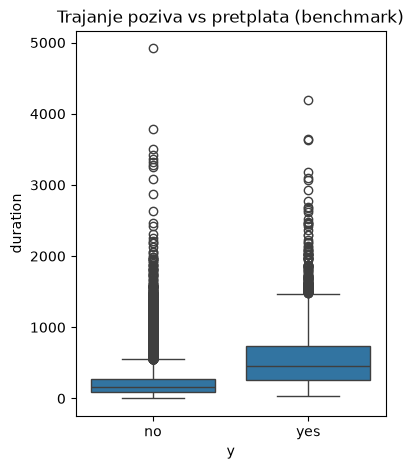

In [13]:
plt.figure(figsize=(4,5))
sns.boxplot(x='y', y='duration', data=df)
plt.title('Trajanje poziva vs pretplata (benchmark)')
plt.show()

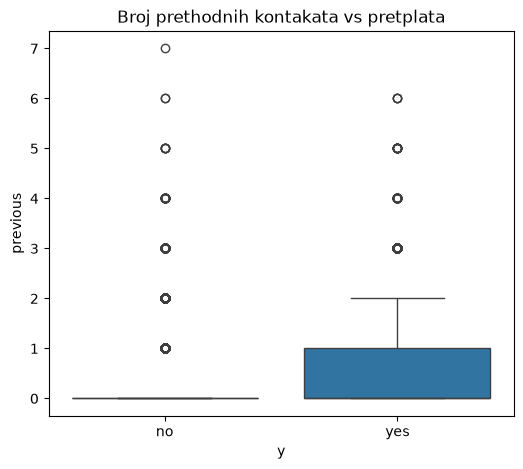

In [14]:
plt.figure(figsize=(6,5))
sns.boxplot(x='y', y='previous', data=df)
plt.title('Broj prethodnih kontakata vs pretplata')
plt.show()